<a href="https://colab.research.google.com/github/tdineth/Neural-Network---Deep-Learning-CO5420-4th-sem/blob/main/lab02/Introduction_to_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 01: Manual vs. Library Implementation of a Perceptron

In [ ]:
import numpy as np

###  Define the Dataset

In [ ]:
x = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]) # This stores the inputs.

y = np.array([0,0,0,1]) # This stores the correct answers.

The lab uses the AND logic gate.

AND gate truth table:

| x1 | x2 | Output |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 0      |
| 1  | 0  | 0      |
| 1  | 1  | 1      |


What is a Perceptron?

A perceptron is the simplest type of artificial neuron.

It:

* takes inputs
* multiplies them by weights
* adds a bias
* decides output using an activation function

Basic idea:






$text{Output} =
\begin{cases}
1 & \text{if } wx + b \ge 0 \\
0 & \text{otherwise}
\end{cases}$







This is called a **step function**.

Think of it like:

* Inputs = evidence
* Weights = importance of evidence
* Bias = adjustment value
* Step function = final YES/NO decision

### Manual Implementation of Perceptron

In [ ]:
def step_function(x):
  return 1 if x >= 0 else 0

In [ ]:
np.zeros(x.shape[1])

array([0., 0.])

In [ ]:
def perceptron_training(x, y, learning_rate=0.1, epochs=10):
    weights = np.zeros(x.shape[1]) # weights Initialization - Initially the model knows nothing (weights = [0,0])
    bias = 0 # bias Initialization
    # Bias is an extra adjustable value.
    # shifting the decision boundary left or right.

    for _ in range(epochs): # Epoch Loop
        # epoch = one full pass through all training data.

        for i in range(len(x)): # Data Loop
        # This goes through each training example one by one.
            activation = np.dot(x[i], weights) + bias
            # x1​w1​+x2​w2​+b
            prediction = step_function(activation)
            # If activation ≥ 0:
            #   prediction = 1
            # Otherwise:
            #   prediction = 0

            error = y[i] - prediction
            weights += learning_rate * error * x[i]
            bias += learning_rate * error

    return weights, bias

Example:

Suppose:

* input = [1,1]
* weights = [0.2,0.3]
* bias = -0.1

Then:

$
(1)(0.2) + (1)(0.3) - 0.1
= 0.4
$


Error Calculation
Example:

| Actual | Predicted | Error |
| ------ | --------- | ----- |
| 1      | 0         | 1     |
| 0      | 1         | -1    |
| 1      | 1         | 0     |

Perceptron learning rule:

$w_{new}=w_{old}+\eta(error)x$

Where:

* $\eta$ = learning rate
* error = actual − predicted
* x = input

In [ ]:
weights, bias = perceptron_training(x,y)
print("Manual Weights",weights)
print("Manual Bias",bias)

Manual Weights [0.2 0.1]
Manual Bias -0.20000000000000004


### Ready-Made Implementation using sklearn

In [ ]:
from sklearn.linear_model import Perceptron

In [ ]:
model = Perceptron(
    max_iter=1000, # maximum training iterations
    eta0=0.1, # learning rate
    random_state=42 # keeps results reproducible
)

model.fit(x,y)

Perceptron(eta0=0.1, random_state=42)

In [ ]:
print("Sklearn Weights:", model.coef_)
print("Sklearn Bias:", model.intercept_)

Sklearn Weights: [[0.2 0.2]]
Sklearn Bias: [-0.2]


### Compare Results

In [ ]:
manual_predictions = [step_function(np.dot(x, weights) + bias) for x in x]
sklearn_predictions = model.predict(x)
print("Manual Predictions:", manual_predictions)
print("Sklearn Predictions:", sklearn_predictions)

Manual Predictions: [0, 0, 0, 1]
Sklearn Predictions: [0 0 0 1]


**Important Concept: Linearly Separable**

A perceptron can solve problems where classes can be separated using a straight line.

AND gate:

```text
Can separate using one line
```

XOR gate:

```text
Cannot separate using one line
```

That is why XOR fails in a single-layer perceptron.


1. Similarities and differences between manual and sklearn implementation?

- Similarities

  * Both use perceptron learning
  * Both update weights and bias
  * Both perform classification

- Differences

  * Manual implementation shows internal working clearly
  * sklearn is optimized and easier to use
  * sklearn has more built-in features

2. Why use sklearn in practice?

    Because it:

      * saves time
      * is optimized
      * is reliable
      * handles large datasets
      * provides many ML tools

# Task 02: Logical Gate Classification

A perceptron learns to separate classes using a straight line.

For logic gates:

- AND → separable
- OR → separable
- NOT → separable
- XOR → NOT separable

## Part 1: AND Gate

In [ ]:
x = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

| x1 | x2 | Output |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 0      |
| 1  | 0  | 0      |
| 1  | 1  | 1      |


In [ ]:
model = Perceptron(
    max_iter=1000, # maximum training iterations
    eta0=0.1, # learning rate
    random_state=42 # keeps results reproducible
)

model.fit(x,y)

Perceptron(eta0=0.1, random_state=42)

In [ ]:
y_pred = model.predict(x)
y_pred

array([0, 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y, y_pred)
)

Accuracy: 1.0


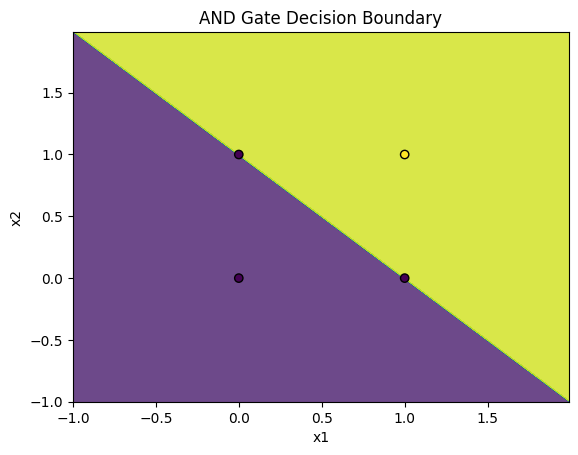

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

x_min, x_max = x[:,0].min()-1, x[:,0].max()+1
y_min, y_max = x[:,1].min()-1, x[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)

plt.scatter(
    x[:,0],
    x[:,1],
    c=y,
    edgecolor='k'
)

plt.title("AND Gate Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

## Part 2: OR Gate


| x1 | x2 | Output |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 1      |
| 1  | 0  | 1      |
| 1  | 1  | 1      |



In [ ]:
x = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,1])

In [ ]:
model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

model.fit(x, y)

Perceptron(eta0=0.1, random_state=42)

In [ ]:
y_pred = model.predict(x)

print(y_pred)

[0 1 1 1]


In [ ]:
print(
    "Accuracy:",
    accuracy_score(y, y_pred)
)

Accuracy: 1.0


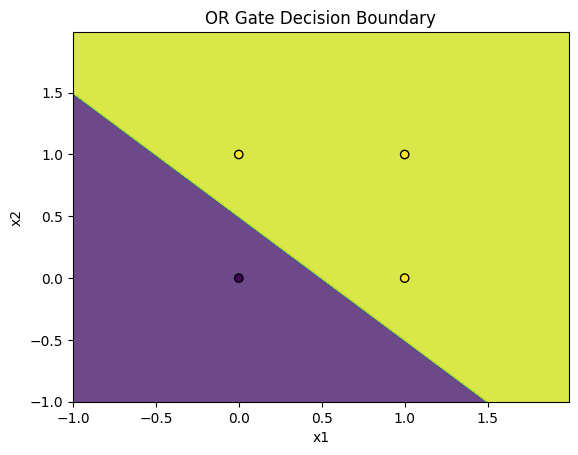

In [ ]:
import matplotlib.pyplot as plt

x_min, x_max = x[:,0].min()-1, x[:,0].max()+1
y_min, y_max = x[:,1].min()-1, x[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)

plt.scatter(
    x[:,0],
    x[:,1],
    c=y,
    edgecolor='k'
)

plt.title("OR Gate Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

## Part 3: NOT Gate

| x | Output |
| - | ------ |
| 0 | 1      |
| 1 | 0      |


In [ ]:
x = np.array([
    [0],
    [1]
])

y = np.array([1,0])

In [ ]:
model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

model.fit(x, y)

Perceptron(eta0=0.1, random_state=42)

In [ ]:
y_pred = model.predict(x)

print(y_pred)

[1 0]


In [ ]:
print(
    "Accuracy:",
    accuracy_score(y, y_pred)
)

Accuracy: 1.0


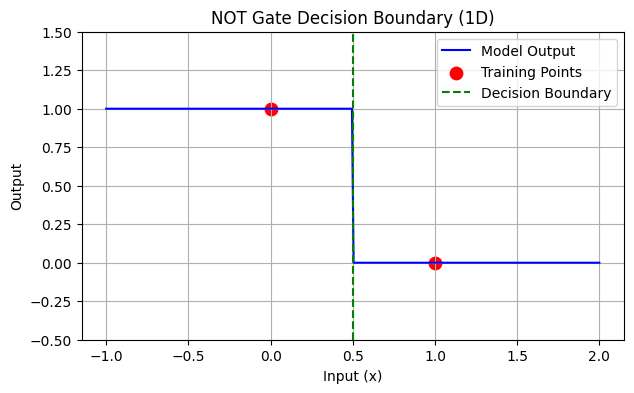

In [ ]:
# Create a range of x-values for visualization
x_range = np.linspace(-1, 2, 300).reshape(-1, 1)
y_range = model.predict(x_range)

plt.figure(figsize=(7,4))

# Plot model predictions
plt.plot(x_range, y_range, label="Model Output", color="blue")

# Plot actual data points
plt.scatter(x, y, color="red", s=80, label="Training Points")

# Decision boundary: solve w*x + b = 0
w = model.coef_[0][0]
b = model.intercept_[0]
decision_boundary = -b / w

plt.axvline(x=decision_boundary, color="green", linestyle="--", label="Decision Boundary")

plt.ylim(-0.5, 1.5)
plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.title("NOT Gate Decision Boundary (1D)")
plt.legend()
plt.grid(True)
plt.show()

### All logic gates combined

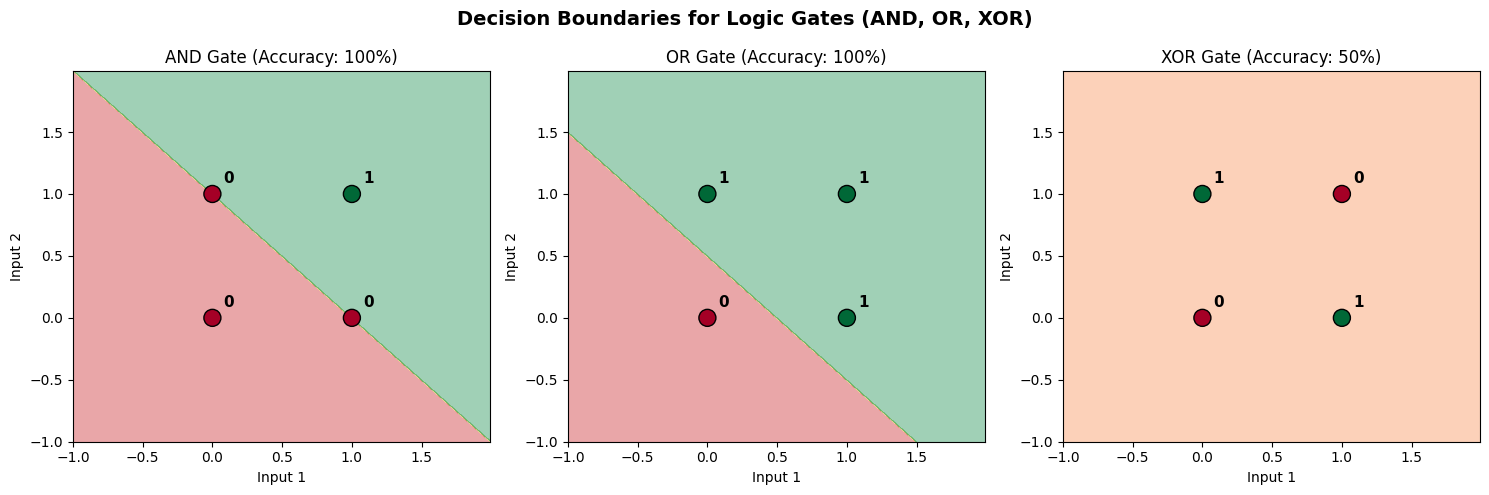

In [ ]:
# Define all logic gates
gates = {
    'AND': {'X': np.array([[0,0],[0,1],[1,0],[1,1]]), 'y': np.array([0,0,0,1])},
    'OR':  {'X': np.array([[0,0],[0,1],[1,0],[1,1]]), 'y': np.array([0,1,1,1])},
    'NOT': {'X': np.array([[0],[1]]),                 'y': np.array([1,0])},
    'XOR': {'X': np.array([[0,0],[0,1],[1,0],[1,1]]), 'y': np.array([0,1,1,0])},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Decision Boundaries for Logic Gates (AND, OR, XOR)', fontsize=14, fontweight='bold')

gates_2d = ['AND', 'OR', 'XOR']

for idx, gate_name in enumerate(gates_2d):
    X_g = gates[gate_name]['X']
    y_g = gates[gate_name]['y']

    model_g = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
    model_g.fit(X_g, y_g)
    y_pred = model_g.predict(X_g)
    acc = accuracy_score(y_g, y_pred)

    # print(f"{gate_name} Gate -> Accuracy: {acc:.2f}, Predictions: {list(y_pred)}, Expected: {list(y_g)}")

    ax = axes[idx]
    x_min, x_max = X_g[:, 0].min() - 1, X_g[:, 0].max() + 1
    y_min, y_max = X_g[:, 1].min() - 1, X_g[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model_g.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
    scatter = ax.scatter(X_g[:, 0], X_g[:, 1], c=y_g, edgecolor='k',
                         s=150, cmap='RdYlGn', zorder=5)
    ax.set_title(f'{gate_name} Gate (Accuracy: {acc:.0%})')
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')

    for j, (xi, yi, label) in enumerate(zip(X_g[:,0], X_g[:,1], y_g)):
        ax.annotate(str(label), (xi, yi), textcoords='offset points',
                    xytext=(8, 8), fontsize=11, fontweight='bold')

plt.tight_layout()
# plt.savefig('task02_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
for gate_name in gates_2d:
    X_g = gates[gate_name]['X']
    y_g = gates[gate_name]['y']

    model_g = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
    model_g.fit(X_g, y_g)

    y_pred = model_g.predict(X_g)
    acc = accuracy_score(y_g, y_pred)

    print(f"\n{'='*40}")
    print(f"{gate_name} GATE")
    print(f"{'='*40}")
    print(f"Accuracy   : {acc:.2%}")
    print(f"Predicted  : {y_pred.tolist()}")
    print(f"Expected   : {y_g.tolist()}")


AND GATE
Accuracy   : 100.00%
Predicted  : [0, 0, 0, 1]
Expected   : [0, 0, 0, 1]

OR GATE
Accuracy   : 100.00%
Predicted  : [0, 1, 1, 1]
Expected   : [0, 1, 1, 1]

XOR GATE
Accuracy   : 50.00%
Predicted  : [0, 0, 0, 0]
Expected   : [0, 1, 1, 0]


In [ ]:
# NOT Gate
X_not = gates['NOT']['X']
y_not = gates['NOT']['y']

model_not = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model_not.fit(X_not, y_not)

y_pred_not = model_not.predict(X_not)
acc_not = accuracy_score(y_not, y_pred_not)

print("\n" + "="*40)
print("NOT GATE")
print("="*40)
print(f"Accuracy   : {acc_not:.2%}")
print(f"Predicted  : {y_pred_not.tolist()}")
print(f"Expected   : {y_not.tolist()}")


NOT GATE
Accuracy   : 100.00%
Predicted  : [1, 0]
Expected   : [1, 0]


### Learning Rate Effect Study

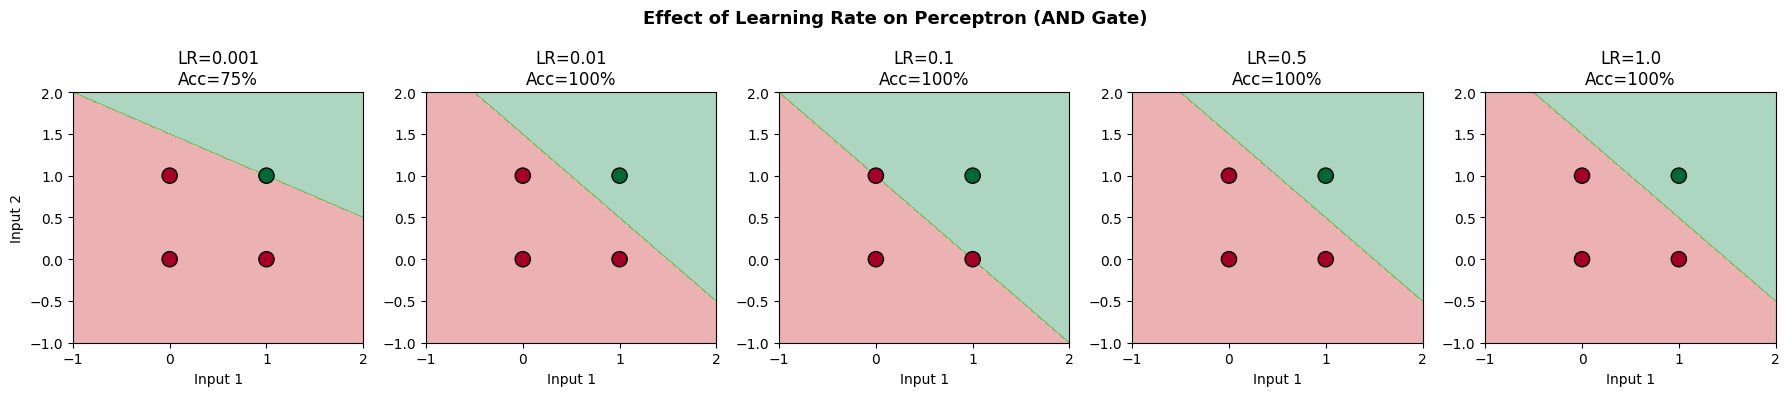

In [ ]:
# Effect of learning rate on AND gate training
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
X_and = gates['AND']['X']
y_and = gates['AND']['y']

fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 4))
fig.suptitle('Effect of Learning Rate on Perceptron (AND Gate)', fontsize=13, fontweight='bold')

for idx, lr in enumerate(learning_rates):
    m = Perceptron(max_iter=1000, eta0=lr, random_state=42)
    m.fit(X_and, y_and)
    preds = m.predict(X_and)
    acc = accuracy_score(y_and, preds)

    ax = axes[idx]
    xx, yy = np.meshgrid(np.arange(-1, 2.01, 0.01), np.arange(-1, 2.01, 0.01))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdYlGn')
    ax.scatter(X_and[:,0], X_and[:,1], c=y_and, edgecolor='k', s=120, cmap='RdYlGn', zorder=5)
    ax.set_title(f'LR={lr}\nAcc={acc:.0%}')
    ax.set_xlabel('Input 1')
    if idx == 0:
        ax.set_ylabel('Input 2')

plt.tight_layout()
plt.show()

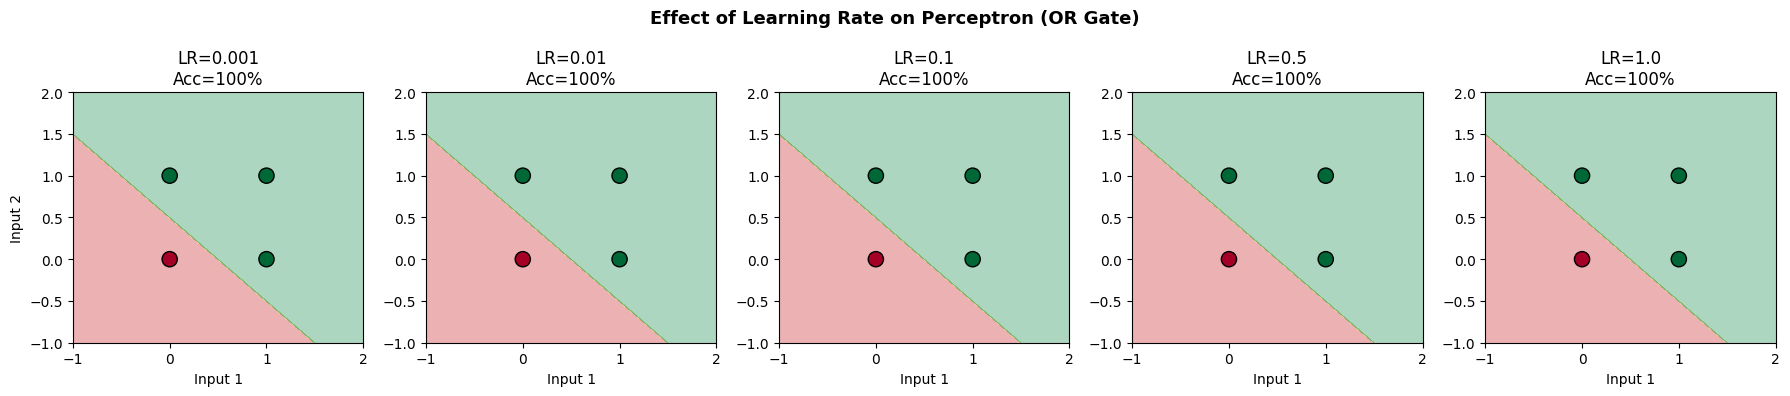

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
X = gates['OR']['X']
y = gates['OR']['y']

fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 4))
fig.suptitle('Effect of Learning Rate on Perceptron (OR Gate)', fontsize=13, fontweight='bold')

for idx, lr in enumerate(learning_rates):
    m = Perceptron(max_iter=1000, eta0=lr, random_state=42)
    m.fit(X, y)

    preds = m.predict(X)
    acc = accuracy_score(y, preds)

    ax = axes[idx]
    xx, yy = np.meshgrid(np.arange(-1, 2.01, 0.01),
                         np.arange(-1, 2.01, 0.01))

    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdYlGn')
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k',
               s=120, cmap='RdYlGn', zorder=5)

    ax.set_title(f'LR={lr}\nAcc={acc:.0%}')
    ax.set_xlabel('Input 1')

    if idx == 0:
        ax.set_ylabel('Input 2')

plt.tight_layout()
plt.show()

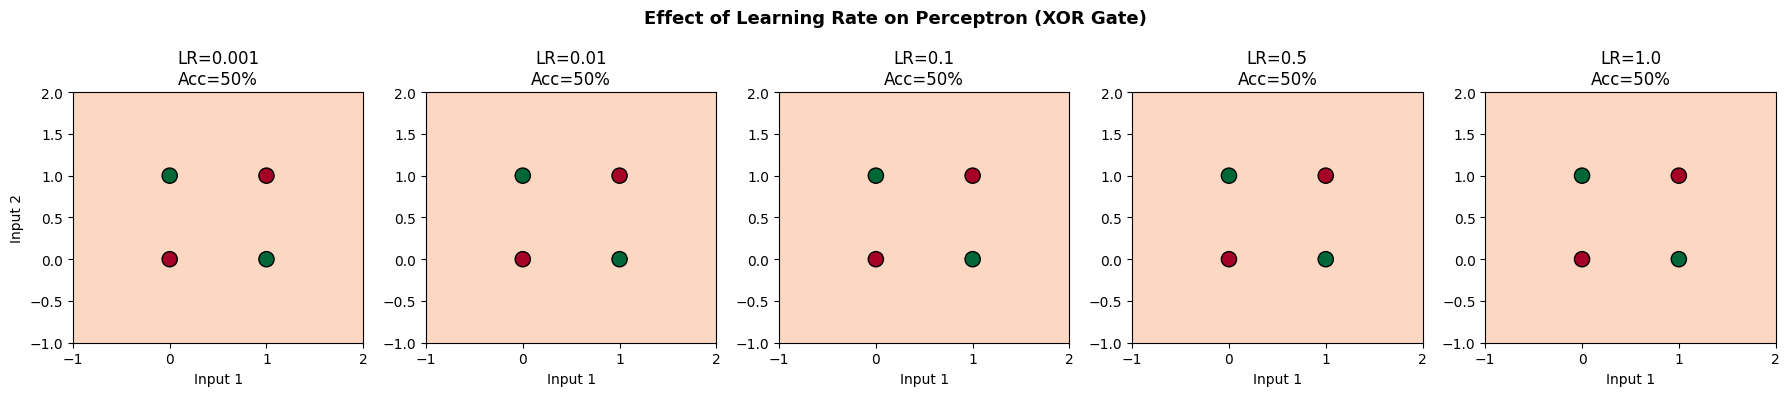

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
X = gates['XOR']['X']
y = gates['XOR']['y']

fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 4))
fig.suptitle('Effect of Learning Rate on Perceptron (XOR Gate)', fontsize=13, fontweight='bold')

for idx, lr in enumerate(learning_rates):
    m = Perceptron(max_iter=1000, eta0=lr, random_state=42)
    m.fit(X, y)

    preds = m.predict(X)
    acc = accuracy_score(y, preds)

    ax = axes[idx]
    xx, yy = np.meshgrid(np.arange(-1, 2.01, 0.01),
                         np.arange(-1, 2.01, 0.01))

    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdYlGn')
    ax.scatter(X[:,0], X[:,1], c=y, edgecolor='k',
               s=120, cmap='RdYlGn', zorder=5)

    ax.set_title(f'LR={lr}\nAcc={acc:.0%}')
    ax.set_xlabel('Input 1')

    if idx == 0:
        ax.set_ylabel('Input 2')

plt.tight_layout()
plt.show()

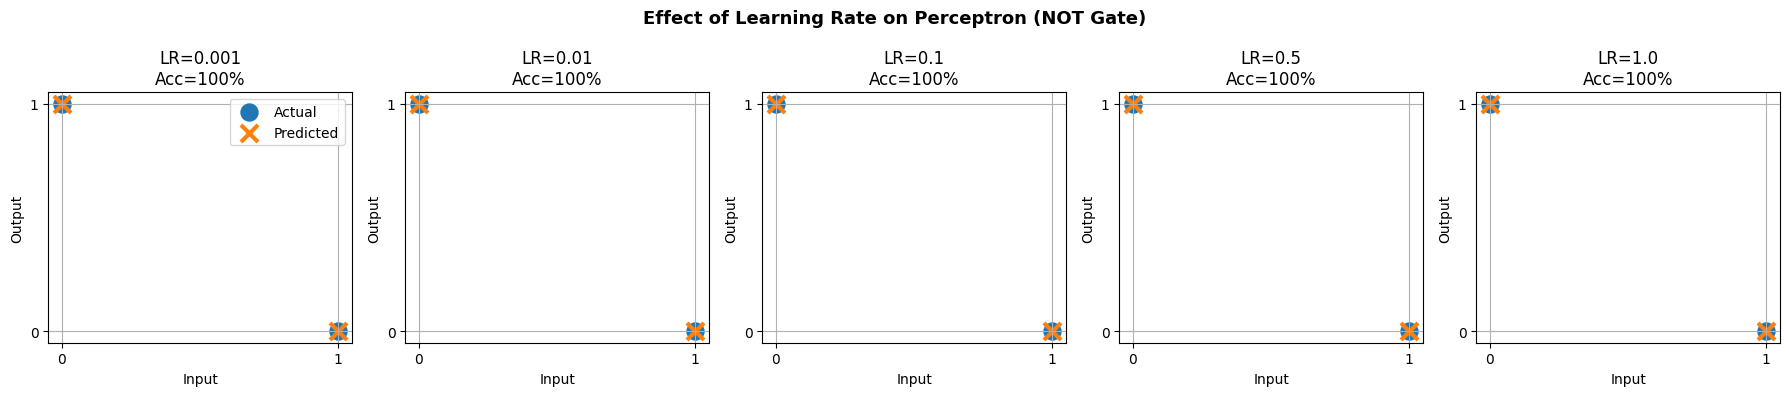

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]

X_not = gates['NOT']['X']
y_not = gates['NOT']['y']

fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 4))
fig.suptitle('Effect of Learning Rate on Perceptron (NOT Gate)',
             fontsize=13, fontweight='bold')

for idx, lr in enumerate(learning_rates):
    model = Perceptron(max_iter=1000, eta0=lr, random_state=42)
    model.fit(X_not, y_not)

    preds = model.predict(X_not)
    acc = accuracy_score(y_not, preds)

    ax = axes[idx]

    # Plot points
    ax.scatter(X_not.flatten(), y_not,
               s=150, label='Actual')

    ax.scatter(X_not.flatten(), preds,
               marker='x', s=150, linewidths=3,
               label='Predicted')

    ax.set_title(f'LR={lr}\nAcc={acc:.0%}')
    ax.set_xlabel('Input')
    ax.set_ylabel('Output')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.grid(True)

    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

### Questions - Task 02

**Q1: Why does a single-layer perceptron fail for certain logic gates, and what are those logic gates?**

A single-layer perceptron can only learn **linearly separable** functions it partitions the input space with a single straight hyperplane. The gate it **fails** on is:

- **XOR (Exclusive OR)**: The truth table outputs `[0, 1, 1, 0]` for inputs `[(0,0), (0,1), (1,0), (1,1)]`. The two classes (0 and 1) cannot be separated by any single straight line, making XOR non-linearly separable. No matter how weights are adjusted, a linear boundary cannot correctly classify all four points simultaneously.

- **XNOR** similarly fails for the same geometric reason.

AND, OR, and NOT are all linearly separable and thus are learned perfectly by a single-layer perceptron.

**Q2: How does adjusting the learning rate affect the perceptron's performance?**

- **Too small (e.g., 0.001)**: Convergence is very slow. The weights update minimally each step, requiring many more epochs to reach a correct solution. On a small dataset like logic gates, it may not converge within a fixed epoch budget.
- **Moderate (e.g., 0.1)**: Provides a good balance - fast enough to converge in few epochs while stable enough not to oscillate around the solution. This is typically the recommended starting point.
- **Too large (e.g., 1.0)**: Weight updates overshoot the optimal boundary. The perceptron may oscillate, never converging, or converge to a suboptimal boundary. For the simple AND/OR gates it may still converge since the problem is easy, but on harder problems large learning rates cause instability.
- In practice, for the AND gate with only 4 training samples, all tested learning rates eventually find a correct classifier because the problem is so simple. The difference in learning rate primarily affects the number of epochs needed and the stability of convergence.

### Task03: Effect of Outliers on Training

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Generate two Gaussian distributions
class1 = np.random.multivariate_normal([2, 2], [[1, 0], [0, 1]], 100)
class2 = np.random.multivariate_normal([5, 5], [[1, 0], [0, 1]], 100)

# Add an outlier
class2_with_outlier = np.vstack([class2, [10, 10]])

# Labels
X = np.vstack([class1, class2_with_outlier])
y = np.hstack([np.ones(100), -np.ones(101)])

print(f"Dataset shape: {X.shape}, Labels: {np.unique(y)}")
print(f"Class 1 samples: {np.sum(y==1)}, Class 2 samples (with outlier): {np.sum(y==-1)}")

Dataset shape: (201, 2), Labels: [-1.  1.]
Class 1 samples: 100, Class 2 samples (with outlier): 101


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Model WITH outlier ---
model_with = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model_with.fit(X_train, y_train)
y_pred_with = model_with.predict(X_test)
acc_with = accuracy_score(y_test, y_pred_with)
print(f"Accuracy WITH outlier: {acc_with:.4f}")

# --- Model WITHOUT outlier (remove the [10,10] point) ---
outlier_mask = ~((X[:, 0] == 10) & (X[:, 1] == 10))
X_clean = X[outlier_mask]
y_clean = y[outlier_mask]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42
)
model_clean = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model_clean.fit(X_train_c, y_train_c)
y_pred_clean = model_clean.predict(X_test_c)
acc_clean = accuracy_score(y_test_c, y_pred_clean)
print(f"Accuracy WITHOUT outlier: {acc_clean:.4f}")

Accuracy WITH outlier: 0.9344
Accuracy WITHOUT outlier: 0.9833


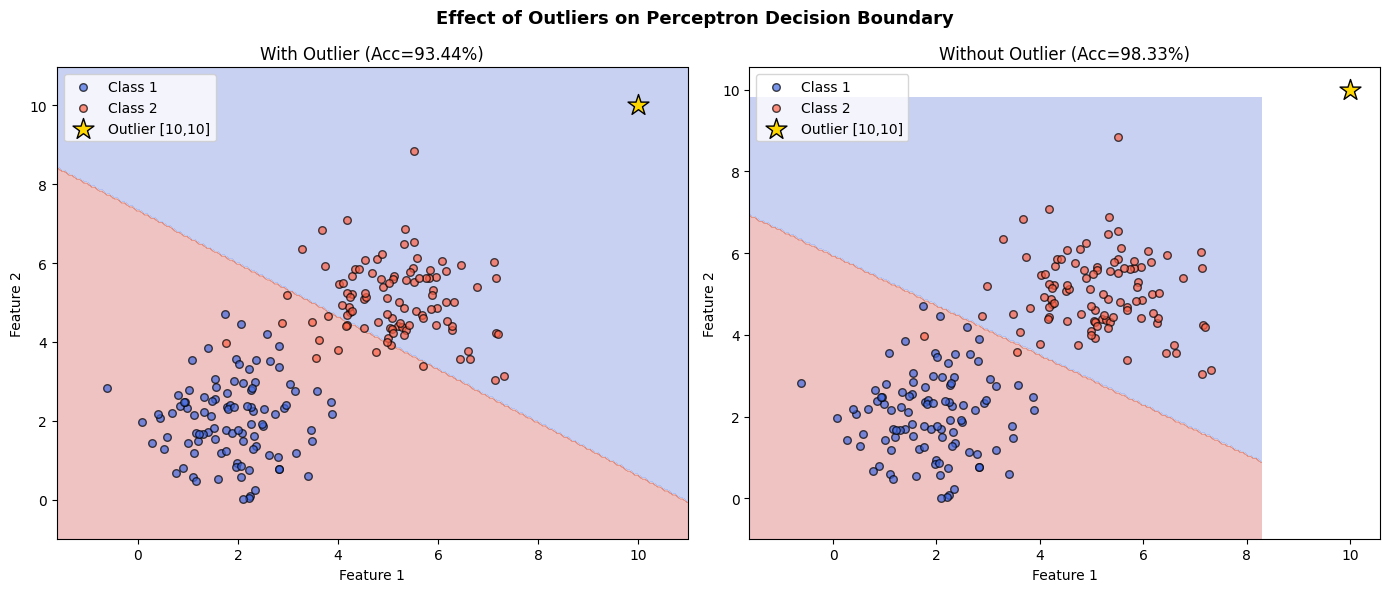

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Effect of Outliers on Perceptron Decision Boundary', fontsize=13, fontweight='bold')

for ax, model, title, X_data, y_data in [
    (axes[0], model_with, f'With Outlier (Acc={acc_with:.2%})', X, y),
    (axes[1], model_clean, f'Without Outlier (Acc={acc_clean:.2%})', X_clean, y_clean)
]:
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    c1_mask = y_data == 1
    c2_mask = y_data == -1
    ax.scatter(X_data[c1_mask, 0], X_data[c1_mask, 1], c='royalblue',
               edgecolor='k', s=30, label='Class 1', alpha=0.7)
    ax.scatter(X_data[c2_mask, 0], X_data[c2_mask, 1], c='tomato',
               edgecolor='k', s=30, label='Class 2', alpha=0.7)

    # Highlight outlier
    if 'With' in title:
        ax.scatter([10], [10], c='gold', edgecolor='black', s=250,
                   marker='*', zorder=10, label='Outlier [10,10]')

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Questions - Task 03

**Q1: How does the presence of outliers affect training time and accuracy?**

- **Training time**: Outliers can significantly increase training time. Because the perceptron updates weights whenever a misclassification occurs, a distant outlier that is consistently misclassified (or forces other points to be misclassified) causes more weight update cycles. This can prevent convergence or require many more epochs before the loss stabilizes, especially if the outlier lies far from the natural decision boundary.

- **Accuracy**: Outliers can degrade accuracy by distorting the learned decision boundary. The perceptron attempts to classify all training points correctly; an extreme outlier like `[10, 10]` biases the boundary away from the true separation between the two Gaussian clusters, leading to misclassifications of regular test samples. As observed, accuracy drops when the outlier is included because the hyperplane is pulled toward the outlier, leaving some normally-distributed points on the wrong side.

**Q2: What strategies can be used to mitigate the effect of outliers?**

1. **Data preprocessing / outlier removal**: Use statistical methods (Z-score, IQR, Isolation Forest, DBSCAN) to detect and remove outliers before training.
2. **Robust scaling**: Apply `RobustScaler` (uses median and IQR instead of mean/std) so that outliers don't dominate feature normalization.
3. **Regularization**: Adding L2 regularization (available via `penalty='l2'` in sklearn Perceptron) constrains weight magnitudes, reducing sensitivity to individual extreme points.
4. **Use robust models**: Support Vector Machines with a soft margin (C parameter) allow some misclassifications and are more robust to outliers than a strict perceptron.
5. **Ensemble methods**: Bagging or boosting approaches average over multiple models trained on different subsets, diluting the influence of any single outlier.
6. **Weighted loss**: Down-weight training samples identified as potential outliers based on their distance from cluster centers.

## Task 04: Real-World Classification (Digit Recognition: 0 vs 1)

Total samples: 360 (Digit 0: 178, Digit 1: 182)
Feature dimensions: 64 (8x8 pixel images flattened)


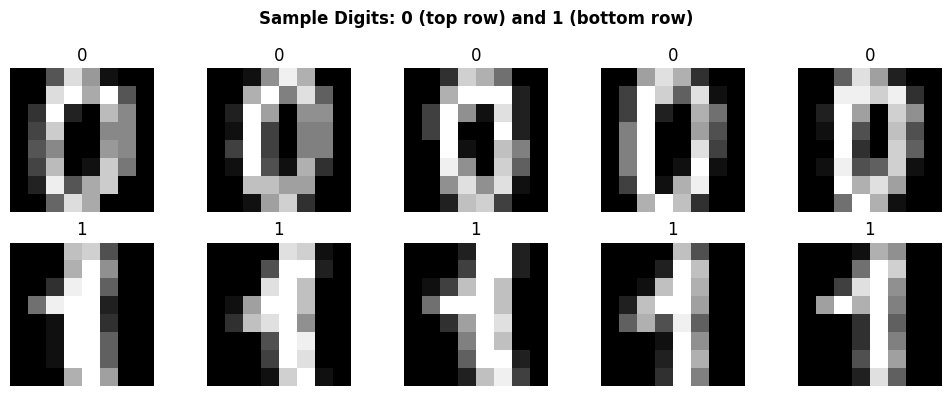

Feature scaling applied (StandardScaler).


In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load Dataset
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X = digits.data[mask]
y = digits.target[mask]

print(f"Total samples: {len(X)} (Digit 0: {np.sum(y==0)}, Digit 1: {np.sum(y==1)})")
print(f"Feature dimensions: {X.shape[1]} (8x8 pixel images flattened)")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Sample Digits: 0 (top row) and 1 (bottom row)', fontsize=12, fontweight='bold')
digits_0 = digits.images[digits.target == 0]
digits_1 = digits.images[digits.target == 1]
for i in range(5):
    axes[0, i].imshow(digits_0[i], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('0')
    axes[1, i].imshow(digits_1[i], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('1')
plt.tight_layout()
plt.savefig('task04_sample_digits.png', dpi=150, bbox_inches='tight')
plt.show()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling applied (StandardScaler).")

In [ ]:
# Step 2: Train the Perceptron
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Model trained successfully.
Training samples: 252, Test samples: 108


In [ ]:
# Step 3: Evaluate Performance
y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Confusion Matrix:
 [[56  0]
 [ 0 52]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           1       1.00      1.00      1.00        52

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108

Overall Accuracy: 1.0000


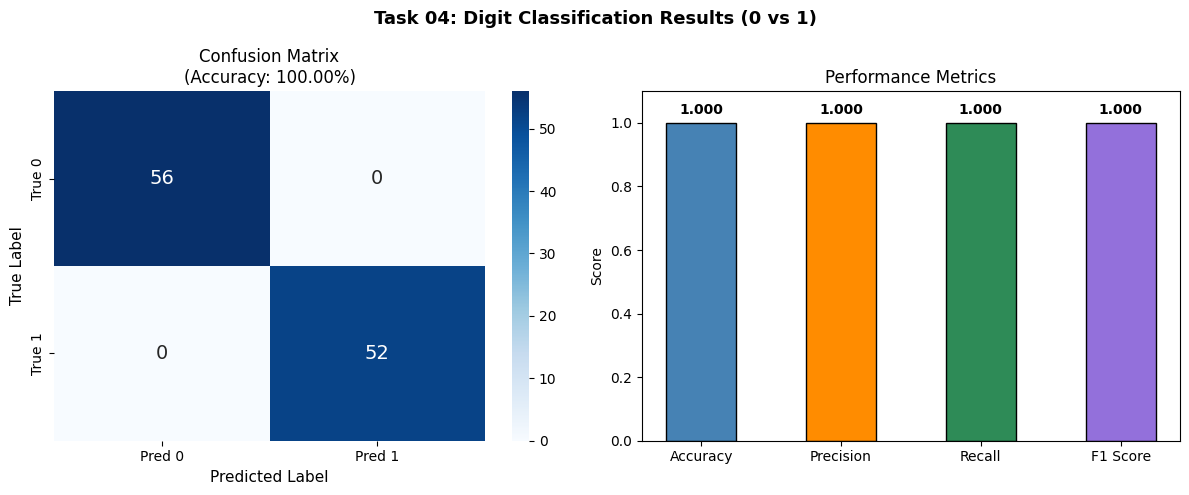

In [ ]:
# Step 4: Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 04: Digit Classification Results (0 vs 1)', fontsize=13, fontweight='bold')

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'], ax=axes[0], annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix\n(Accuracy: {accuracy_score(y_test, y_pred):.2%})')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Bar chart of metrics
from sklearn.metrics import precision_score, recall_score, f1_score
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred, average='weighted'),
}
bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=['steelblue', 'darkorange', 'seagreen', 'mediumpurple'],
                   edgecolor='black', width=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Performance Metrics')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Questions - Task 04

**Q: What changes would you make to improve accuracy?**

1. **Multi-Layer Perceptron (MLP)**: Replace the single-layer perceptron with a multi-layer neural network using `sklearn.neural_network.MLPClassifier` or PyTorch/TensorFlow. Hidden layers allow learning non-linear features in the pixel space, dramatically improving digit recognition.

2. **Feature engineering / dimensionality reduction**: Apply PCA to reduce 64 features to the most informative principal components, reducing noise and potentially improving generalization.

3. **Convolutional layers**: Use a CNN (Convolutional Neural Network) that exploits the spatial structure of 8×8 images by learning local filters — much more suitable for image classification than a flat perceptron.

4. **Better preprocessing**: While StandardScaler is already applied, experimenting with min-max normalization or whitening (ZCA) could further help.

5. **Hyperparameter tuning**: Use `GridSearchCV` to optimize learning rate (`eta0`), number of iterations (`max_iter`), regularization type (`penalty`) and strength (`alpha`).

6. **More training data / data augmentation**: With small datasets, augmenting images (slight rotations, shifts) increases effective training set size and improves robustness.

7. **SVM with RBF kernel**: For this binary classification task, an SVM can find a better maximum-margin boundary in the high-dimensional pixel space, typically outperforming a perceptron.